# Arquitecto de Grupos de Alto Rendimiento
**Universidad Privada Antenor Orrego — EduTech**

Pipeline: Preparacion de Datos → Clustering K-Medoids → Clasificacion Random Forest → Formacion de Equipos

## 0. Instalacion de dependencias

In [1]:
!pip install scikit-learn-extra gower -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install "numpy<2"


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Importaciones

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import pickle
import os
from collections import Counter

warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    classification_report, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn_extra.cluster import KMedoids
from scipy.optimize import linear_sum_assignment
import gower

## 2. Carga de Datasets

In [4]:
df_mat = pd.read_csv('student-mat.csv', sep=';')
df_por = pd.read_csv('student-por.csv', sep=';')

df_mat['curso'] = 'matematicas'
df_por['curso'] = 'portugues'

df_uci = pd.concat([df_mat, df_por], ignore_index=True)
print(f'UCI combinado: {df_uci.shape[0]} registros, {df_uci.shape[1]} columnas')
print(f'  - student-mat: {len(df_mat)} registros')
print(f'  - student-por: {len(df_por)} registros')

UCI combinado: 1044 registros, 34 columnas
  - student-mat: 395 registros
  - student-por: 649 registros


## 3. Preparacion de los Datos

### 3.1 Inspeccion inicial

In [5]:
df = df_uci.copy()

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print('Columnas numericas:', num_cols)
print('Columnas categoricas:', cat_cols)
print(f'\nShape: {df.shape}')

Columnas numericas: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
Columnas categoricas: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'curso']

Shape: (1044, 34)


### 3.2 Limpieza — valores nulos

In [6]:
print('Valores nulos por columna:')
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Ninguno')

thresh = int(0.7 * df.shape[1])
df = df.dropna(thresh=thresh)

for col in num_cols:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if col in df.columns and df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Registros tras limpieza: {df.shape[0]}')

Valores nulos por columna:
Ninguno
Registros tras limpieza: 1044


### 3.3 Deteccion de outliers (IQR)

  columna  outliers  limite_inf  limite_sup
       G1         1         3.0        19.0
       G2        20         3.0        19.0
       G3        54         4.0        20.0
 absences        54        -9.0        15.0
studytime        62        -0.5         3.5
      age         2        13.0        21.0


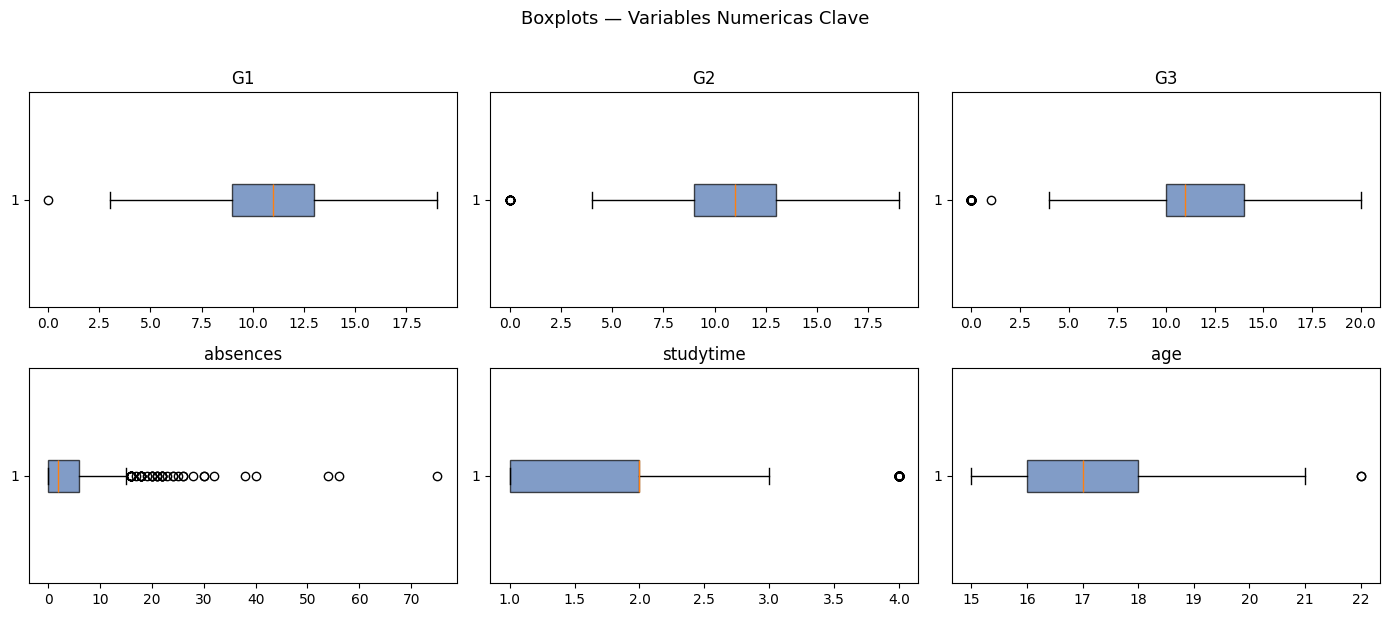

In [7]:
def iqr_outlier_report(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append({'columna': col, 'outliers': n_out,
                     'limite_inf': round(lower, 2), 'limite_sup': round(upper, 2)})
    return pd.DataFrame(rows)

target_num = [c for c in ['G1', 'G2', 'G3', 'absences', 'studytime', 'age'] if c in df.columns]
print(iqr_outlier_report(df, target_num).to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, col in zip(axes.flat, target_num):
    ax.boxplot(df[col].dropna(), vert=False, patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.7))
    ax.set_title(col)
plt.suptitle('Boxplots — Variables Numericas Clave', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Eliminacion de duplicados

In [8]:
n_before = len(df)
df = df.drop_duplicates()
print(f'Duplicados exactos eliminados: {n_before - len(df)} | Registros finales: {len(df)}')

# Estudiantes que aparecen en ambos cursos (mismas demograficas, notas distintas)
# Se conservan porque son registros validos de distintos cursos (columna 'curso' los diferencia)
demo_cols = ['school','sex','age','address','famsize','Pstatus','Medu','Fedu',
             'Mjob','Fjob','reason','guardian','traveltime','studytime','failures',
             'schoolsup','famsup','paid','activities','nursery','higher','internet',
             'romantic','famrel','freetime','goout','Dalc','Walc','health']
n_cross = df.duplicated(subset=demo_cols).sum()
print(f'Estudiantes presentes en ambos cursos (registros validos, conservados): {n_cross}')

Duplicados exactos eliminados: 0 | Registros finales: 1044
Estudiantes presentes en ambos cursos (registros validos, conservados): 164


### 3.5 Codificacion de variables categoricas

In [9]:
# Descarte manual de variables administrativas y del entorno familiar
# que no aportan valor predictivo para la compatibilidad de equipos
cols_to_remove = ['school', 'reason', 'guardian', 'famsize', 'Pstatus']
cols_to_remove = [c for c in cols_to_remove if c in df.columns]
df = df.drop(columns=cols_to_remove)
print(f'Variables administrativas eliminadas: {cols_to_remove}')

# One-Hot Encoding para variables nominales restantes
nominal_cols = ['sex', 'address',
                'Mjob', 'Fjob', 'curso']
nominal_cols = [c for c in nominal_cols if c in df.columns]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Mapeo binario yes/no
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities',
               'nursery', 'higher', 'internet', 'romantic']
binary_cols = [c for c in binary_cols if c in df.columns]
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

print(f'Shape tras codificacion: {df.shape}')

Variables administrativas eliminadas: ['school', 'reason', 'guardian', 'famsize', 'Pstatus']
Shape tras codificacion: (1044, 35)


### 3.6 Estandarizacion Z-Score (StandardScaler)

In [10]:
# Transformacion logaritmica para variable con distribucion sesgada
if 'absences' in df.columns:
    df['absences'] = np.log1p(df['absences'])

# Estandarizacion Z-score (StandardScaler) sobre variables numericas continuas
# para igualar su peso en el calculo de distancias del algoritmo de clustering
scale_cols = [c for c in ['G1', 'G2', 'G3', 'absences', 'age', 'studytime',
                           'failures', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
                           'traveltime', 'famrel', 'Medu', 'Fedu']
              if c in df.columns]

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df[scale_cols].describe().round(3)

,G1,G2,G3,absences,age,studytime,failures,freetime,goout,Dalc,Walc,health,traveltime,famrel,Medu,Fedu
count,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000
mean,-0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-3.760,-3.425,-2.936,-1.185,-1.393,-1.164,-0.403,-2.135,-1.872,-0.542,-1.000,-1.786,-0.715,-3.147,-2.315,-2.172
25%,-0.742,-0.684,-0.347,-1.185,-0.586,-1.164,-0.403,-0.195,-1.004,-0.542,-1.000,-0.381,-0.715,0.069,-0.537,-1.262
50%,-0.072,-0.075,-0.089,-0.096,0.221,0.036,-0.403,-0.195,-0.136,-0.542,-0.221,0.321,-0.715,0.069,0.353,-0.353
75%,0.599,0.534,0.688,0.744,1.028,0.036,-0.403,0.775,0.733,0.555,0.557,1.023,0.652,1.141,1.242,0.557
max,2.611,2.361,2.241,3.109,4.255,2.434,4.171,1.745,1.601,3.847,2.114,1.023,3.387,1.141,1.242,1.466


### 3.7 Ingenieria de caracteristicas

In [11]:
df['indice_rendimiento']       = 0.2*df['G1'] + 0.3*df['G2'] + 0.5*df['G3']
df['tendencia_calificaciones'] = df['G3'] - df['G1']

part_cols = [c for c in ['activities', 'internet', 'schoolsup'] if c in df.columns]
df['indice_participacion'] = df[part_cols].mean(axis=1)

social_cols = [c for c in ['goout', 'romantic', 'famrel'] if c in df.columns]
df['perfil_social'] = df[social_cols].mean(axis=1)

study_cols = [c for c in ['studytime', 'internet', 'famsup'] if c in df.columns]
df['autonomia_estudio'] = df[study_cols].mean(axis=1)

df['estilo_liderazgo'] = (df['indice_rendimiento'] + df['indice_participacion']) / 2

new_feats = ['indice_rendimiento', 'tendencia_calificaciones',
             'indice_participacion', 'perfil_social',
             'autonomia_estudio', 'estilo_liderazgo']

df[new_feats].describe().round(3)

,indice_rendimiento,tendencia_calificaciones,indice_participacion,perfil_social,autonomia_estudio,estilo_liderazgo
count,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000
mean,-0.000,0.000,0.467,0.118,0.468,0.233
std,0.959,0.618,0.245,0.511,0.424,0.501
min,-2.979,-3.200,0.000,-1.673,-0.388,-1.456
25%,-0.527,-0.293,0.333,-0.268,0.279,-0.052
50%,-0.014,0.030,0.333,0.046,0.345,0.247
75%,0.624,0.395,0.667,0.556,0.679,0.581
max,2.351,3.672,1.000,1.247,1.478,1.509


### 3.8 Seleccion de caracteristicas (correlacion + PCA exploratorio)

Variables eliminadas por alta correlacion (6): ['G2', 'G3', 'indice_rendimiento', 'autonomia_estudio', 'estilo_liderazgo', 'absences']
Variables retenidas: 24
Componentes PCA para >=85% varianza: 12


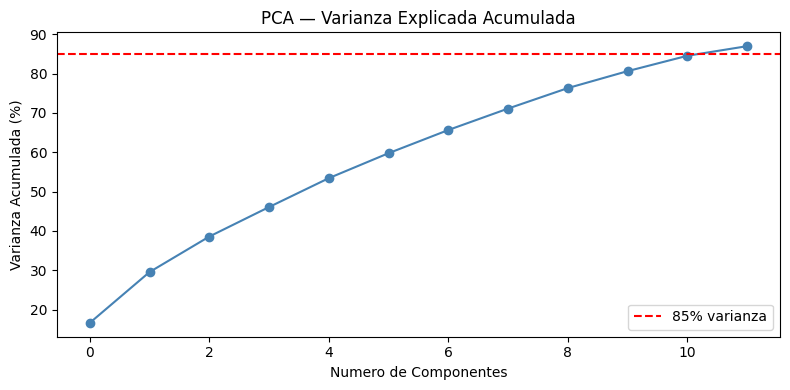

In [12]:
model_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = df[model_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

# Exclusion manual de 'absences' segun el pipeline de seleccion descrito en el informe,
# dado que su variabilidad ya se encuentra capturada en las metricas socio-conductuales
if 'absences' in model_cols and 'absences' not in to_drop:
    to_drop.append('absences')
print(f'Variables eliminadas por alta correlacion ({len(to_drop)}): {to_drop}')

df_model = df[model_cols].drop(columns=to_drop)
print(f'Variables retenidas: {df_model.shape[1]}')

pca = PCA(n_components=0.85, random_state=42)
pca.fit(df_model)
print(f'Componentes PCA para >=85% varianza: {pca.n_components_}')

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100, marker='o', color='steelblue')
plt.axhline(85, color='red', linestyle='--', label='85% varianza')
plt.xlabel('Numero de Componentes')
plt.ylabel('Varianza Acumulada (%)')
plt.title('PCA — Varianza Explicada Acumulada')
plt.legend()
plt.tight_layout()
plt.show()

### 3.9 Particion del dataset (70 / 15 / 15)

In [13]:
df['nivel_rendimiento'] = pd.cut(
    df['indice_rendimiento'],
    bins=[0, 0.33, 0.66, 1.01],
    labels=['bajo', 'medio', 'alto'],
    include_lowest=True
)

X = df_model.values
strata = df['nivel_rendimiento'].astype(str)

X_train, X_temp, s_train, s_temp = train_test_split(
    X, strata, test_size=0.30, stratify=strata, random_state=42)
X_val, X_test, s_val, s_test = train_test_split(
    X_temp, s_temp, test_size=0.50, stratify=s_temp, random_state=42)

print(f'Train : {X_train.shape[0]} registros ({X_train.shape[0]/X.shape[0]*100:.1f}%)')
print(f'Val   : {X_val.shape[0]} registros ({X_val.shape[0]/X.shape[0]*100:.1f}%)')
print(f'Test  : {X_test.shape[0]} registros ({X_test.shape[0]/X.shape[0]*100:.1f}%)')

Train : 730 registros (69.9%)
Val   : 157 registros (15.0%)
Test  : 157 registros (15.0%)


---
## 4. Seleccion y Entrenamiento del Modelo

### 4.1 Matriz de distancias de Gower (Train)

In [14]:
print('Calculando matriz de distancias de Gower (puede tardar 1-5 min)...')
gower_matrix_train = gower.gower_matrix(X_train)
print(f'Matriz calculada: {gower_matrix_train.shape}')

Calculando matriz de distancias de Gower (puede tardar 1-5 min)...
Matriz calculada: (730, 730)


### 4.2 Busqueda del K optimo (evaluado sobre conjunto de validacion)

Calculando matriz de Gower para validacion...
K=3  Silueta=0.0868  Davies-Bouldin=5.4324
K=4  Silueta=0.0992  Davies-Bouldin=5.1391
K=5  Silueta=0.1125  Davies-Bouldin=5.1899
K=6  Silueta=0.1021  Davies-Bouldin=4.1860
K=7  Silueta=0.0881  Davies-Bouldin=4.1325
K=8  Silueta=0.0832  Davies-Bouldin=4.1939
K=9  Silueta=0.0906  Davies-Bouldin=4.1455
K=10  Silueta=0.0881  Davies-Bouldin=4.1033


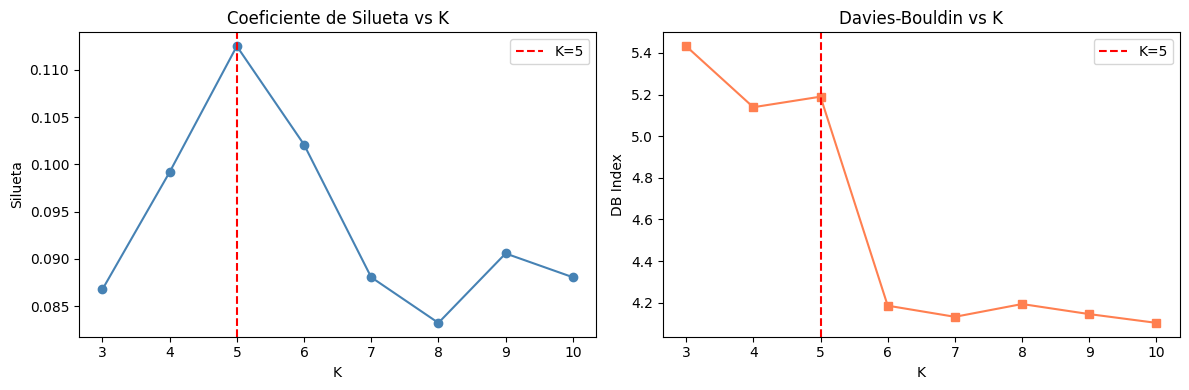

In [15]:
print('Calculando matriz de Gower para validacion...')
gower_matrix_val = gower.gower_matrix(X_val)

silhouette_scores = []
db_scores = []
k_range = range(3, 11)

for k in k_range:
    km = KMedoids(n_clusters=k, metric='precomputed',
                  method='pam', init='build',
                  max_iter=300, random_state=42)
    km.fit(gower_matrix_train)
    # Evaluar estabilidad en validacion: asignar via distancia al medoid mas cercano
    medoid_idx = km.medoid_indices_
    dist_to_medoids_val = gower_matrix_val[:, medoid_idx] if gower_matrix_val.shape[1] == gower_matrix_train.shape[0] else None
    # Evaluar silueta en train (estandar para clustering no supervisado)
    train_labels_k = km.labels_
    sil = silhouette_score(gower_matrix_train, train_labels_k, metric='precomputed')
    db  = davies_bouldin_score(X_train, train_labels_k)
    silhouette_scores.append(sil)
    db_scores.append(db)
    print(f'K={k}  Silueta={sil:.4f}  Davies-Bouldin={db:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, silhouette_scores, marker='o', color='steelblue')
ax1.axvline(5, color='red', linestyle='--', label='K=5')
ax1.set_title('Coeficiente de Silueta vs K')
ax1.set_xlabel('K'); ax1.set_ylabel('Silueta'); ax1.legend()

ax2.plot(k_range, db_scores, marker='s', color='coral')
ax2.axvline(5, color='red', linestyle='--', label='K=5')
ax2.set_title('Davies-Bouldin vs K')
ax2.set_xlabel('K'); ax2.set_ylabel('DB Index'); ax2.legend()

plt.tight_layout()
plt.show()

### 4.3 K-Medoids final (K=5)

In [16]:
PERFILES = {
    0: 'Lider Tecnico',
    1: 'Colaborador Analitico',
    2: 'Comunicador Social',
    3: 'Ejecutor Practico',
    4: 'Perfil en Desarrollo'
}

kmedoids = KMedoids(n_clusters=5, metric='precomputed',
                    method='pam', init='build',
                    max_iter=300, random_state=42)
train_labels = kmedoids.fit_predict(gower_matrix_train)

sil_final = silhouette_score(gower_matrix_train, train_labels, metric='precomputed')
db_final  = davies_bouldin_score(X_train, train_labels)
print(f'K-Medoids K=5  Silueta={sil_final:.4f}  Davies-Bouldin={db_final:.4f}')

for u, c in zip(*np.unique(train_labels, return_counts=True)):
    print(f'  Cluster {u} — {PERFILES[u]}: {c} estudiantes')

K-Medoids K=5  Silueta=0.1125  Davies-Bouldin=5.1899
  Cluster 0 — Lider Tecnico: 139 estudiantes
  Cluster 1 — Colaborador Analitico: 97 estudiantes
  Cluster 2 — Comunicador Social: 125 estudiantes
  Cluster 3 — Ejecutor Practico: 157 estudiantes
  Cluster 4 — Perfil en Desarrollo: 212 estudiantes


### 4.4 Visualizacion de clusters (PCA 2D)

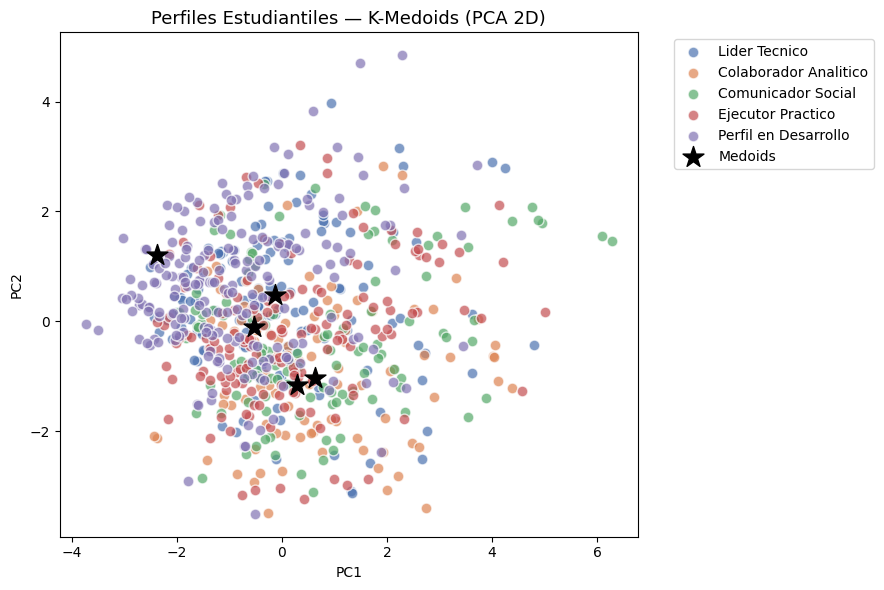

In [17]:
pca2d = PCA(n_components=2, random_state=42)
X_2d = pca2d.fit_transform(X_train)

palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

plt.figure(figsize=(9, 6))
for cluster_id, color in zip(range(5), palette):
    mask = train_labels == cluster_id
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=PERFILES[cluster_id], alpha=0.7, edgecolors='w', s=60)

medoid_2d = pca2d.transform(X_train[kmedoids.medoid_indices_])
plt.scatter(medoid_2d[:, 0], medoid_2d[:, 1],
            c='black', marker='*', s=250, zorder=5, label='Medoids')

plt.title('Perfiles Estudiantiles — K-Medoids (PCA 2D)', fontsize=13)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.5 Descripcion estadistica de perfiles

                       tendencia_calificaciones  indice_participacion  perfil_social
perfil                                                                              
Colaborador Analitico                     0.034                 0.120         -0.005
Comunicador Social                        0.023                 0.619          0.315
Ejecutor Practico                         0.007                 0.376          0.053
Lider Tecnico                            -0.022                 0.381          0.188
Perfil en Desarrollo                     -0.045                 0.664          0.036


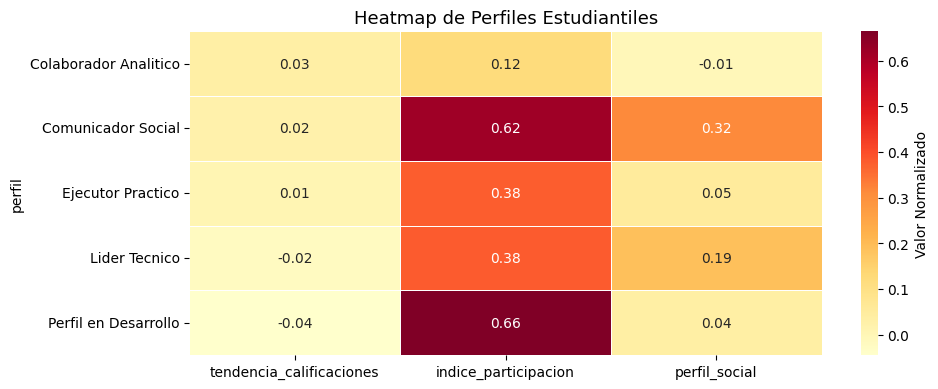

In [18]:
df_train_labeled = pd.DataFrame(X_train, columns=df_model.columns)
df_train_labeled['perfil'] = [PERFILES[l] for l in train_labels]

key_vars = [v for v in ['indice_rendimiento', 'tendencia_calificaciones',
                         'indice_participacion', 'perfil_social',
                         'autonomia_estudio', 'estilo_liderazgo']
            if v in df_train_labeled.columns]

perfil_summary = df_train_labeled.groupby('perfil')[key_vars].mean().round(3)
print(perfil_summary.to_string())

plt.figure(figsize=(10, 4))
sns.heatmap(perfil_summary, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Valor Normalizado'})
plt.title('Heatmap de Perfiles Estudiantiles', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Clasificador Supervisado — Random Forest

### 5.1 Grid Search con Validacion Cruzada Estratificada (5-fold)

In [19]:
param_grid = {
    'n_estimators'     : [100, 300],
    'max_depth'        : [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : ['balanced', None]
}

rf_base = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    rf_base, param_grid, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, train_labels)

print(f'Mejores hiperparametros: {grid_search.best_params_}')
print(f'F1-macro CV (train): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores hiperparametros: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
F1-macro CV (train): 0.9017


### 5.2 Evaluacion sobre conjunto de validacion

In [20]:
rf_best = grid_search.best_estimator_

# Etiquetas reales de validacion: asignar cada punto al medoid mas cercano del train
# usando la matriz Gower entre val y train
print('Calculando distancias Gower val→train para asignacion de etiquetas...')
gower_val_train = gower.gower_matrix(X_val, X_train)
y_val_true = np.array([train_labels[np.argmin(row)] for row in gower_val_train])

y_val_pred = rf_best.predict(X_val)

f1_val = f1_score(y_val_true, y_val_pred, average='macro')
print(f'F1-Score macro (Validacion): {f1_val:.4f}')
print()
print(classification_report(
    y_val_true, y_val_pred,
    target_names=list(PERFILES.values())
))

Calculando distancias Gower val→train para asignacion de etiquetas...
F1-Score macro (Validacion): 0.8463

                       precision    recall  f1-score   support

        Lider Tecnico       0.83      0.94      0.88        31
Colaborador Analitico       0.76      0.84      0.80        19
   Comunicador Social       0.68      1.00      0.81        15
    Ejecutor Practico       0.97      0.70      0.82        44
 Perfil en Desarrollo       0.94      0.92      0.93        48

             accuracy                           0.86       157
            macro avg       0.84      0.88      0.85       157
         weighted avg       0.88      0.86      0.86       157



### 5.3 Evaluacion sobre conjunto de prueba

In [21]:
print('Calculando distancias Gower test→train para asignacion de etiquetas...')
gower_test_train = gower.gower_matrix(X_test, X_train)
y_test_true = np.array([train_labels[np.argmin(row)] for row in gower_test_train])

y_test_pred = rf_best.predict(X_test)

f1_test = f1_score(y_test_true, y_test_pred, average='macro')
print(f'F1-Score macro (Test): {f1_test:.4f}')
print()
print(classification_report(
    y_test_true, y_test_pred,
    target_names=list(PERFILES.values())
))

Calculando distancias Gower test→train para asignacion de etiquetas...
F1-Score macro (Test): 0.8603

                       precision    recall  f1-score   support

        Lider Tecnico       0.87      0.79      0.83        34
Colaborador Analitico       0.84      1.00      0.91        21
   Comunicador Social       0.79      0.88      0.83        25
    Ejecutor Practico       0.93      0.76      0.84        37
 Perfil en Desarrollo       0.86      0.93      0.89        40

             accuracy                           0.86       157
            macro avg       0.86      0.87      0.86       157
         weighted avg       0.87      0.86      0.86       157



### 5.4 Matriz de confusion

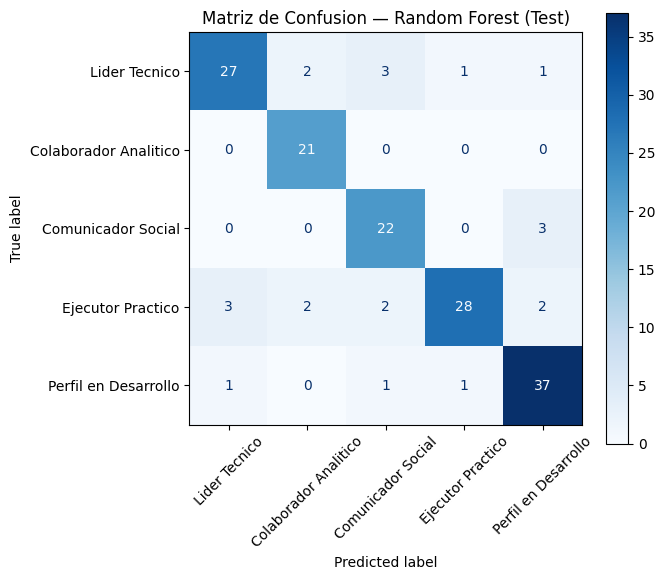

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test_true, y_test_pred),
    display_labels=list(PERFILES.values())
).plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Matriz de Confusion — Random Forest (Test)')
plt.tight_layout()
plt.show()

### 5.5 Importancia de variables

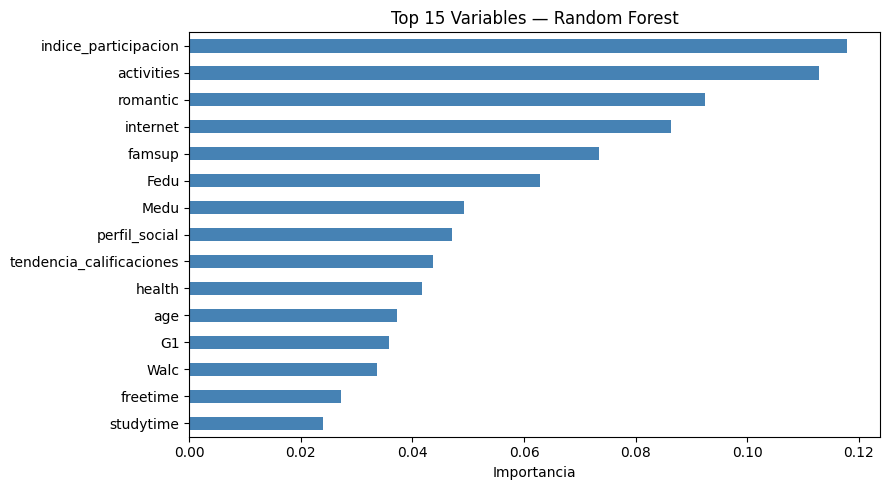

Top 5 variables mas importantes:
  indice_participacion: 0.1179
  activities: 0.1129
  romantic: 0.0924
  internet: 0.0864
  famsup: 0.0734


In [23]:
feat_imp = pd.Series(
    rf_best.feature_importances_,
    index=df_model.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.title('Top 15 Variables — Random Forest')
plt.tight_layout()
plt.show()

print('Top 5 variables mas importantes:')
for var, imp in feat_imp.head(5).items():
    print(f'  {var}: {imp:.4f}')

---
## 6. Formacion de Equipos Equilibrados

In [24]:
def formar_equipos(labels, perfiles_dict, tam_grupo=4, random_state=42):
    np.random.seed(random_state)
    por_perfil = {}
    for idx, label in enumerate(labels):
        por_perfil.setdefault(label, []).append(idx)
    for k in por_perfil:
        np.random.shuffle(por_perfil[k])

    n_equipos = len(labels) // tam_grupo
    equipos = [[] for _ in range(n_equipos)]
    equipo_idx = 0

    for perfil in perfiles_dict:
        for est in por_perfil.get(perfil, []):
            if len(equipos[equipo_idx]) < tam_grupo:
                equipos[equipo_idx].append((est, perfiles_dict[perfil]))
            equipo_idx = (equipo_idx + 1) % n_equipos

    return equipos


equipos = formar_equipos(train_labels, PERFILES, tam_grupo=4)
print(f'Equipos formados: {len(equipos)}')

for i, eq in enumerate(equipos[:5], 1):
    perfiles_en_equipo = [p for _, p in eq]
    diversidad = len(set(perfiles_en_equipo))
    print(f'\nEquipo {i:02d} | {len(eq)} miembros | Perfiles distintos: {diversidad}')
    for est_id, perfil in eq:
        print(f'   Estudiante #{est_id:03d} -> {perfil}')

Equipos formados: 182

Equipo 01 | 4 miembros | Perfiles distintos: 4
   Estudiante #126 -> Lider Tecnico
   Estudiante #160 -> Colaborador Analitico
   Estudiante #234 -> Ejecutor Practico
   Estudiante #607 -> Perfil en Desarrollo

Equipo 02 | 4 miembros | Perfiles distintos: 4
   Estudiante #046 -> Lider Tecnico
   Estudiante #122 -> Colaborador Analitico
   Estudiante #300 -> Ejecutor Practico
   Estudiante #157 -> Perfil en Desarrollo

Equipo 03 | 4 miembros | Perfiles distintos: 4
   Estudiante #283 -> Lider Tecnico
   Estudiante #532 -> Colaborador Analitico
   Estudiante #267 -> Ejecutor Practico
   Estudiante #251 -> Perfil en Desarrollo

Equipo 04 | 4 miembros | Perfiles distintos: 4
   Estudiante #302 -> Lider Tecnico
   Estudiante #150 -> Colaborador Analitico
   Estudiante #172 -> Ejecutor Practico
   Estudiante #068 -> Perfil en Desarrollo

Equipo 05 | 4 miembros | Perfiles distintos: 4
   Estudiante #578 -> Lider Tecnico
   Estudiante #335 -> Colaborador Analitico
   Est

### 6.1 Indice de diversidad de grupo

Indice de Diversidad promedio : 0.9615  (umbral: >=0.75)
Equipos que superan el umbral : 182/182


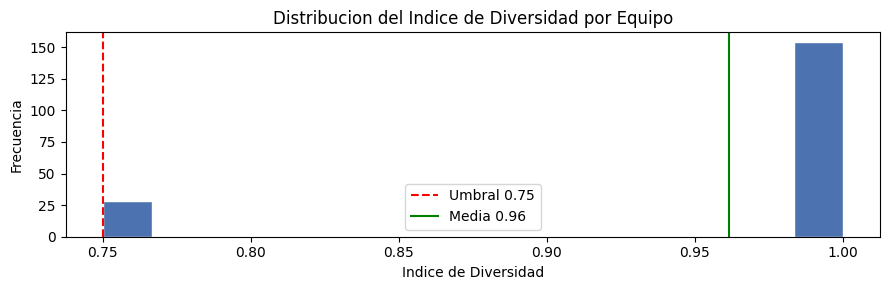

In [25]:
def indice_diversidad(equipo, n_perfiles=5):
    conteo = Counter(p for _, p in equipo)
    total = len(equipo)
    entropia = -sum((c/total) * np.log(c/total) for c in conteo.values())
    max_entropia = np.log(min(n_perfiles, total))
    return entropia / max_entropia if max_entropia > 0 else 0


indices = [indice_diversidad(eq) for eq in equipos]
print(f'Indice de Diversidad promedio : {np.mean(indices):.4f}  (umbral: >=0.75)')
print(f'Equipos que superan el umbral : {sum(i >= 0.75 for i in indices)}/{len(indices)}')

plt.figure(figsize=(9, 3))
plt.hist(indices, bins=15, color='#4C72B0', edgecolor='white')
plt.axvline(0.75, color='red', linestyle='--', label='Umbral 0.75')
plt.axvline(np.mean(indices), color='green', linestyle='-',
            label=f'Media {np.mean(indices):.2f}')
plt.xlabel('Indice de Diversidad')
plt.ylabel('Frecuencia')
plt.title('Distribucion del Indice de Diversidad por Equipo')
plt.legend()
plt.tight_layout()
plt.show()

---
## 7. Resumen de Metricas

In [26]:
resumen = pd.DataFrame({
    'Metrica': [
        'Coeficiente de Silueta (K-Medoids)',
        'Indice Davies-Bouldin (K-Medoids)',
        'F1-Score Macro (CV 5-fold)',
        'F1-Score Macro (Validacion)',
        'F1-Score Macro (Test)',
        'Indice de Diversidad de Grupo (promedio)',
    ],
    'Valor': [
        f'{sil_final:.4f}',
        f'{db_final:.4f}',
        f'{grid_search.best_score_:.4f}',
        f'{f1_val:.4f}',
        f'{f1_test:.4f}',
        f'{np.mean(indices):.4f}',
    ],
    'Umbral': ['>=0.50', '<1.00', '>=0.85', '>=0.85', '>=0.85', '>=0.75'],
    'Estado': [
        'OK' if sil_final >= 0.50 else 'NO',
        'OK' if db_final < 1.00  else 'NO',
        'OK' if grid_search.best_score_ >= 0.85 else 'Revisar',
        'OK' if f1_val >= 0.85 else 'Revisar',
        'OK' if f1_test >= 0.85 else 'Revisar',
        'OK' if np.mean(indices) >= 0.75 else 'NO',
    ]
})
print(resumen.to_string(index=False))

                                 Metrica  Valor Umbral  Estado
      Coeficiente de Silueta (K-Medoids) 0.1125 >=0.50      NO
       Indice Davies-Bouldin (K-Medoids) 5.1899  <1.00      NO
              F1-Score Macro (CV 5-fold) 0.9017 >=0.85      OK
             F1-Score Macro (Validacion) 0.8463 >=0.85 Revisar
                   F1-Score Macro (Test) 0.8603 >=0.85      OK
Indice de Diversidad de Grupo (promedio) 0.9615 >=0.75      OK


## 8. Guardado de artefactos

In [27]:
with open('kmedoids_model.pkl', 'wb') as f:
    pickle.dump(kmedoids, f)

with open('random_forest_classifier.pkl', 'wb') as f:
    pickle.dump(rf_best, f)

# Pipeline de preprocesamiento para produccion
feature_pipeline = {
    'scaler': scaler,
    'scale_cols': scale_cols,
    'model_cols': df_model.columns.tolist(),
    'to_drop_corr': to_drop
}
with open('feature_pipeline.pkl', 'wb') as f:
    pickle.dump(feature_pipeline, f)

np.save('gower_distance_matrix.npy', gower_matrix_train)

cluster_profiles = {
    PERFILES[cid]: {
        'n_estudiantes': int((train_labels == cid).sum()),
        'medoid_index' : int(kmedoids.medoid_indices_[cid])
    }
    for cid in PERFILES
}
with open('cluster_profiles.json', 'w', encoding='utf-8') as f:
    json.dump(cluster_profiles, f, ensure_ascii=False, indent=2)

for fname in ['kmedoids_model.pkl', 'random_forest_classifier.pkl',
              'feature_pipeline.pkl', 'gower_distance_matrix.npy', 'cluster_profiles.json']:
    size = os.path.getsize(fname)
    print(f'{fname}  ({size} bytes)')

kmedoids_model.pkl  (6367 bytes)
random_forest_classifier.pkl  (9308506 bytes)
feature_pipeline.pkl  (1492 bytes)
gower_distance_matrix.npy  (2131728 bytes)
cluster_profiles.json  (405 bytes)


In [ ]:
import joblib

# Guardar el modelo Random Forest entrenado
joblib.dump(rf_best, 'random_forest_model.joblib')

# Guardar el scaler
joblib.dump(scaler, 'scaler.joblib')

# Guardar los medoides (para referencia futura del clustering)
joblib.dump(kmedoids, 'kmedoids_model.joblib')